
# MODEL SIMULATION

This notebook reproduces simulating the biologically plausible **forward varying-volatility** agent and the **Weber-imprecision** agent from Findling et al. (2021) paper titled *'Imprecise neural computations as a source of adaptive behaviour in volatile environments'*.

```
Folder Structure 

neural-imprecision-for-volatility/     
└── findling_notebook/                 ← OUR REPO
    ├── 1.simulation_data
    ├── 2.fitting_data
    ├── images_and_figures/  
    ├── result_figures  
├── notebook_fitting_optimised.ipynb 
├── notebook_model_simulation        
├── fit_functions/                     ← Original C++ code
├── lib_c/                             
├── simulation_functions/              
└── utils/                             

```
________________________________________________________________________________


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font")
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
from scipy.stats import ttest_ind



### Step 1: Task and environment generation

In [6]:
@dataclass
class VolatileBanditTask:
    """Container that stores a whole task instance for re-use across agents."""
    stimuli: np.ndarray  # here it is always zero but kept for completeness
    latent_states: np.ndarray  # z_t, the true task-set index
    switch_prob: np.ndarray  # τ_t
    traps: np.ndarray  # Bernoulli noise on rewards
    correct_actions: np.ndarray  # action that yields positive feedback if there is no trap
    beta: float  # feedback reliability parameter η in the paper



In [7]:
class TwoArmedBanditEnv:
    """Minimal environment that feeds the agents with stimuli and rewards."""

    def __init__(self, task: VolatileBanditTask):
        self.task = task
        self.index = 0

    def reset(self):
        self.index = 0

    def step(self, action: int) -> Tuple[int, int, int]:
        """Play one trial and return (stimulus, reward, correct_action)."""
        stimulus = self.task.stimuli[self.index]
        correct_action = self.task.correct_actions[self.index]
        trap = self.task.traps[self.index]

        if action == correct_action:
            reward = int(not trap)
        else:
            reward = int(trap)

        self.index += 1
        return stimulus, reward, correct_action


### Step 2: Particle filtering utilities - the sequential Monte Carlo (SMC) algorithm

The forward models in the repo maintain two layers of particles:

1. **State particles** encode beliefs over latent task-sets `z_t` and, for the varying-volatility agent, the latent hazard `τ_t`.
2. **Parameter particles** encode beliefs over the hyper-parameters `(β, ν, γ)` (varying volatility) or `(β, γ)` (Weber).

We reproduce the exact helper routines (stratified resampling, inverse-gamma sampling, etc.) here to keep the notebook self-contained.


In [15]:
def stratified_resample(weights: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Stratified resampling as used in the original C++ code."""
    n = len(weights)
    cumulative = np.cumsum(weights)
    positions = (rng.random(n) + np.arange(n)) / n
    return np.searchsorted(cumulative, positions)


def sample_inv_gamma(shape: float, scale: float, size: int, rng: np.random.Generator) -> np.ndarray:
    """Inverse-gamma sampler matching utils/useful_functions.py."""
    return scale / rng.gamma(shape, size=size)


def logsumexp(log_w: np.ndarray) -> float:
    b = np.max(log_w)
    return b + np.log(np.sum(np.exp(log_w - b)))


def normalise_log_weights(log_w: np.ndarray) -> np.ndarray:
    """Convert log-weights to normalized weights without numerical trouble."""
    log_w = log_w - logsumexp(log_w)
    return np.exp(log_w)


def compute_positive_states(mapping: np.ndarray, stimulus: int, action: int, reward: int) -> np.ndarray:
    """Replicates isEqual_and_adapted_logical_xor from the C++ helpers."""
    equals = mapping[stimulus] == action
    if reward:  # reward==1 means the action was *reported* as correct
        return equals.astype(float)
    return (~equals).astype(float)


def sample_new_state_excluding(current: int, gamma: np.ndarray, rng: np.random.Generator) -> int:
    probs = gamma.copy()
    probs[current] = 0.0
    total = probs.sum()
    if total == 0:
        probs[:] = 1.0 / len(probs)
    else:
        probs /= total
    return rng.choice(len(probs), p=probs)

# Mapping between stimulus (rows) and correct action for each latent state (columns)
TASK_MAPPING = np.array([[0, 1]], dtype=int)
K = TASK_MAPPING.shape[1]  # number of latent states



### Step 3a: Forward varying-volatility agent
This class mirrors `simulation_functions/varvol_forward/SMC2.py` and `lib_c/varvol_forward/SMCfunctions.cpp`:
- Each *theta* particle samples `(β, ν, γ)`.
- Each theta carries `number_of_state_particles` state trajectories that track both latent task-set `z` and latent hazard `τ`.
- After every observation we:
  1. **Update weights** using the Bernoulli feedback likelihood.
  2. **Resample** state trajectories within each theta according to those weights.
  3. **Propagate** the trajectories by sampling a new `τ` and, with probability `τ`, switching to a different task-set drawn from `γ`.
  4. **Adapt** the parameter particles if the effective sample size (ESS) collapses.

The result is a biologically plausible online approximation of the exact SMC² solution.


In [9]:
class ForwardVaryingVolatilityAgent:
    """Forward (online) SMC approximation of the exact varying-volatility model."""

    def __init__(
        self,
        num_theta: int = 500, # c++ default VV 1000, we use 500 for speed
        num_state_particles: int = 500, # c++ default VV 1000, we use 500 for speed
        tau_default: float = 0.03,
        tau_bounds: Tuple[float, float] = (0.0, 1),
        beta_prior: Tuple[float, float] = (1.0, 1.0),
        nu_prior: Tuple[float, float] = (3.0, 1e-3),
        gamma_prior: float = 1.0,
        ess_threshold: float = 0.5,
        beta_softmax: Optional[float] = None,
        epsilon_softmax: float = 0.0,
        seed: Optional[int] = None,
    ):
        self.num_theta = num_theta
        self.num_state_particles = num_state_particles
        self.tau_default = tau_default
        self.tau_bounds = tau_bounds
        self.beta_prior = beta_prior
        self.nu_prior = nu_prior
        self.gamma_prior = gamma_prior
        self.ess_threshold = ess_threshold
        self.beta_softmax = beta_softmax
        self.epsilon_softmax = epsilon_softmax
        self.rng = np.random.default_rng(seed)

        self._init_particles()

    def _init_particles(self):
        self.beta_samples = self.rng.beta(
            self.beta_prior[0], self.beta_prior[1], size=self.num_theta
        )
        self.nu_samples = sample_inv_gamma(
            self.nu_prior[0], self.nu_prior[1], size=self.num_theta, rng=self.rng
        )
        self.gamma_samples = self.rng.dirichlet(
            np.ones(K) * self.gamma_prior, size=self.num_theta
        )
        self.state_particles = self.rng.integers(
            K, size=(self.num_theta, self.num_state_particles)
        )
        self.tau_particles = np.full(
            (self.num_theta, self.num_state_particles), self.tau_default
        )
        self.log_theta_weights = np.zeros(self.num_theta)
        self.theta_weights = np.ones(self.num_theta) / self.num_theta
        self.pending_observation = None
        self.current_action = None
        self.current_stimulus = None
        self.trial_index = 0

        self.history = {
            "vol_mean": [],
            "beta_mean": [],
            "nu_mean": [],
            "ts_prob": [],
        }

    # ------------------------------------------------------------------
    # Agent interaction API
    # ------------------------------------------------------------------
    def act(self, stimulus: int) -> Tuple[int, np.ndarray]:
        self._maybe_smc_update()
        action_probs = self._action_distribution(stimulus)
        action = self._sample_action(action_probs)
        self.current_action = action
        self.current_stimulus = stimulus
        return action, action_probs

    def observe(self, reward: int):
        self.pending_observation = (
            self.current_stimulus,
            self.current_action,
            reward,
        )
        self.trial_index += 1

    # ------------------------------------------------------------------
    # SMC internals
    # ------------------------------------------------------------------
    def _maybe_smc_update(self):
        if self.pending_observation is None:
            return

        stimulus, action, reward = self.pending_observation
        prev_states = self.state_particles.copy()
        prev_taus = self.tau_particles.copy()

        positive_states = compute_positive_states(TASK_MAPPING, stimulus, action, reward)
        # Transform beta from [0,1] to [0.5,1] as in original code: betaSamples/2 + 0.5
        # This ensures feedback noise η > 0.5 (reward is more likely when action is correct)
        beta_transformed = self.beta_samples / 2.0 + 0.5
        beta_matrix = beta_transformed[:, None]
        state_pos = positive_states[prev_states]
        likelihoods = state_pos * beta_matrix + (1 - state_pos) * (1 - beta_matrix)
        likelihoods = np.clip(likelihoods, 1e-9, None)

        sum_weights = likelihoods.sum(axis=1)
        self.log_theta_weights += np.log(sum_weights / self.num_state_particles)
        weights_norm = likelihoods / sum_weights[:, None]

        new_states = np.empty_like(prev_states)
        new_taus = np.empty_like(prev_taus)
        for theta_idx in range(self.num_theta):
            ancestor_idx = stratified_resample(weights_norm[theta_idx], self.rng)
            new_states[theta_idx] = prev_states[theta_idx, ancestor_idx]
            new_taus[theta_idx] = prev_taus[theta_idx, ancestor_idx]

        noise = self.rng.normal(
            0.0,
            np.sqrt(self.nu_samples)[:, None],
            size=new_taus.shape,
        )
        tau_candidates = np.clip(
            new_taus + noise, self.tau_bounds[0], self.tau_bounds[1]
        )
        self.tau_particles = tau_candidates

        switch_mask = self.rng.random(size=new_states.shape) < tau_candidates
        propagated_states = new_states.copy()
        for theta_idx in range(self.num_theta):
            gamma = self.gamma_samples[theta_idx]
            indices = np.where(switch_mask[theta_idx])[0]
            for idx in indices:
                propagated_states[theta_idx, idx] = sample_new_state_excluding(
                    propagated_states[theta_idx, idx], gamma, self.rng
                )
        self.state_particles = propagated_states

        self.pending_observation = None
        self.theta_weights = normalise_log_weights(self.log_theta_weights)
        self._maybe_rejuvenate()
        self._record_history()

    def _maybe_rejuvenate(self):
        ess = 1.0 / np.sum(self.theta_weights ** 2)
        if ess >= self.ess_threshold * self.num_theta:
            return

        beta_mu = np.sum(self.theta_weights * self.beta_samples)
        beta_var = np.sum(self.theta_weights * (self.beta_samples - beta_mu) ** 2)
        beta_var = max(beta_var, 1e-6)
        beta_alpha = max(((1 - beta_mu) / beta_var - 1 / beta_mu) * beta_mu ** 2, 1.0)
        beta_beta = max(beta_alpha * (1 / beta_mu - 1), 1.0)

        nu_mu = np.sum(self.theta_weights * self.nu_samples)
        nu_var = np.sum(self.theta_weights * (self.nu_samples - nu_mu) ** 2)
        nu_var = max(nu_var, 1e-6)
        nu_alpha = nu_mu ** 2 / nu_var + 2.0
        nu_beta = nu_mu * (nu_alpha - 1)

        dirichlet_means = np.sum(
            self.theta_weights[:, None] * self.gamma_samples, axis=0
        )
        dirichlet_vars = np.sum(
            self.theta_weights[:, None] * (self.gamma_samples ** 2), axis=0
        ) - dirichlet_means ** 2
        dirichlet_vars = np.clip(dirichlet_vars, 1e-6, None)
        dirichlet_precision = (
            np.sum(dirichlet_means - dirichlet_means ** 2) / np.sum(dirichlet_vars)
        ) - 1
        dirichlet_precision = max(dirichlet_precision, 1.0)
        dirichlet_params = np.maximum(
            dirichlet_means * dirichlet_precision, 1.0
        )

        self.beta_samples = self.rng.beta(
            beta_alpha, beta_beta, size=self.num_theta
        )
        self.nu_samples = sample_inv_gamma(
            nu_alpha, nu_beta, size=self.num_theta, rng=self.rng
        )
        self.gamma_samples = self.rng.dirichlet(
            dirichlet_params, size=self.num_theta
        )
        self.log_theta_weights[:] = 0.0
        self.theta_weights = np.ones(self.num_theta) / self.num_theta

    def _record_history(self):
        tau_means = self.tau_particles.mean(axis=1)
        vol_mean = np.sum(self.theta_weights * tau_means)
        beta_mean = np.sum(self.theta_weights * self.beta_samples)
        nu_mean = np.sum(self.theta_weights * self.nu_samples)
        ts_prob = self._taskset_probability(self.theta_weights)

        self.history["vol_mean"].append(vol_mean)
        self.history["beta_mean"].append(beta_mean)
        self.history["nu_mean"].append(nu_mean)
        self.history["ts_prob"].append(ts_prob)

    # ------------------------------------------------------------------
    # Decision policy helpers
    # ------------------------------------------------------------------
    def _taskset_probability(self, theta_weights: np.ndarray) -> np.ndarray:
        ts_prob = np.zeros(K)
        for theta_idx in range(self.num_theta):
            counts = np.bincount(
                self.state_particles[theta_idx], minlength=K
            ) / self.num_state_particles
            ts_prob += theta_weights[theta_idx] * counts
        ts_prob /= np.sum(ts_prob)
        return ts_prob

    def _action_distribution(self, stimulus: int) -> np.ndarray:
        ts_prob = self._taskset_probability(self.theta_weights)
        action_probs = np.zeros(2)
        for action in range(2):
            mask = TASK_MAPPING[stimulus] == action
            action_probs[action] = ts_prob[mask].sum()
        if self.beta_softmax is None:
            greedy_action = np.argmax(action_probs)
            probs = np.zeros_like(action_probs)
            probs[greedy_action] = 1.0
            return probs
        logits = action_probs * self.beta_softmax
        logits -= np.max(logits)
        probs = np.exp(logits)
        probs /= probs.sum()
        probs = probs * (1 - self.epsilon_softmax) + self.epsilon_softmax / len(probs)
        return probs

    def _sample_action(self, action_probs: np.ndarray) -> int:
        if np.isclose(action_probs.sum(), 0):
            return self.rng.integers(2)
        if np.count_nonzero(action_probs) == 1:
            return int(np.argmax(action_probs))
        return self.rng.choice(len(action_probs), p=action_probs)



### Step 3b: Weber-imprecision agent
This class mirrors `simulation_functions/noisy_forward/smc2.py` and `lib_c/noisy_forward/smc_functions.cpp`:

The zero-volatility model assumes that the hazard `τ` is fixed (no environmental switches). The Weber-imprecision variant injects noise directly into the particle filter:
- Each theta particle still tracks `(β, γ)`.
- After observing a reward we compute the *distance* `d_t` between the pre-update (`ante`) and post-update (`post`) task-set beliefs (L1 distance, as in the C++ backend).
- The particle mis-encodes the next state with probability `ε_t ~ U(0, μ + λ d_t)`. When a mis-encoding happens the state particle is redrawn from `γ`.

Setting `μ = 0` and `λ = 0` collapses the model back to the deterministic zero-volatility case.


In [8]:
class WeberImprecisionAgent:
    """Forward Weber-imprecision agent (aka precision model)."""

    def __init__(
        self,
        num_theta: int = 500, # c++ default W 1000, 500 for speed
        num_state_particles: int = 1000, # c++ default W 2000, 1000 for speed
        lambdaa: float = 0.9,
        mu: float = 0.0,
        beta_prior: Tuple[float, float] = (1.0, 1.0),
        gamma_prior: float = 1.0,
        ess_threshold: float = 0.5,
        beta_softmax: Optional[float] = None,
        epsilon_softmax: float = 0.0,
        seed: Optional[int] = None,
    ):
        self.num_theta = num_theta
        self.num_state_particles = num_state_particles
        self.lambdaa = lambdaa
        self.mu = mu
        self.beta_prior = beta_prior
        self.gamma_prior = gamma_prior
        self.ess_threshold = ess_threshold
        self.beta_softmax = beta_softmax
        self.epsilon_softmax = epsilon_softmax
        self.rng = np.random.default_rng(seed)

        self._init_particles()

    def _init_particles(self):
        self.beta_samples = self.rng.beta(
            self.beta_prior[0], self.beta_prior[1], size=self.num_theta
        )
        self.gamma_samples = self.rng.dirichlet(
            np.ones(K) * self.gamma_prior, size=self.num_theta
        )
        self.state_particles = self.rng.integers(
            K, size=(self.num_theta, self.num_state_particles)
        )
        self.log_theta_weights = np.zeros(self.num_theta)
        self.theta_weights = np.ones(self.num_theta) / self.num_theta
        self.pending_observation = None
        self.current_action = None
        self.current_stimulus = None

        self.history = {
            "epsilon": [],
            "beta_mean": [],
            "ts_prob": [],
        }

    def act(self, stimulus: int) -> Tuple[int, np.ndarray]:
        self._maybe_smc_update()
        action_probs = self._action_distribution(stimulus)
        action = self._sample_action(action_probs)
        self.current_action = action
        self.current_stimulus = stimulus
        return action, action_probs

    def observe(self, reward: int):
        self.pending_observation = (
            self.current_stimulus,
            self.current_action,
            reward,
        )

    def _maybe_smc_update(self):
        if self.pending_observation is None:
            return

        stimulus, action, reward = self.pending_observation
        prev_states = self.state_particles.copy()

        positive_states = compute_positive_states(TASK_MAPPING, stimulus, action, reward)
        beta_transformed = self.beta_samples / 2.0 + 0.5
        beta_matrix = beta_transformed[:, None]
        state_pos = positive_states[prev_states]
        likelihoods = state_pos * beta_matrix + (1 - state_pos) * (1 - beta_matrix)
        likelihoods = np.clip(likelihoods, 1e-9, None)

        # Compute ante (before update) belief - weighted by current theta weights
        ante_counts = (
            np.apply_along_axis(
                lambda row: np.bincount(row, minlength=K), 1, prev_states
            )
            / self.num_state_particles
        )
        
        sum_weights = likelihoods.sum(axis=1)
        weights_norm = likelihoods / sum_weights[:, None]
        
        # Compute post (after update) belief per theta
        weighted_post = np.zeros_like(ante_counts)
        for theta_idx in range(self.num_theta):
            for state_idx in range(self.num_state_particles):
                s = prev_states[theta_idx, state_idx]
                weighted_post[theta_idx, s] += weights_norm[theta_idx, state_idx]
        weighted_post = np.divide(
            weighted_post,
            weighted_post.sum(axis=1, keepdims=True) + 1e-12,
        )
        
        # === FIX: Compute GLOBAL distance (matching C++) ===
        # Weight ante and post by theta weights to get global beliefs
        # First get current normalized theta weights (before this update)
        current_theta_weights = normalise_log_weights(self.log_theta_weights)
        
        # Global ante belief (weighted average across theta)
        global_ante = np.sum(current_theta_weights[:, None] * ante_counts, axis=0)
        
        # Global post belief (weighted average across theta, with updated weights)
        # Note: C++ uses post-update weights, so we need to compute them
        updated_log_weights = self.log_theta_weights + np.log(sum_weights / self.num_state_particles)
        updated_theta_weights = normalise_log_weights(updated_log_weights)
        global_post = np.sum(updated_theta_weights[:, None] * weighted_post, axis=0)
        
        # Global L1 distance
        global_distance = np.sum(np.abs(global_ante - global_post))
        
        # Single epsilon for all particles (matching C++)
        epsilon = (self.lambdaa * global_distance + self.mu) / 2.0
        epsilon = np.clip(epsilon, 0.0, 0.5)  # Max 0.5 since we divided by 2
        
        self.history["epsilon"].append(epsilon)
        # === END FIX ===

        self.log_theta_weights += np.log(sum_weights / self.num_state_particles)

        new_states = np.empty_like(prev_states)
        for theta_idx in range(self.num_theta):
            ancestor_idx = stratified_resample(weights_norm[theta_idx], self.rng)
            candidates = prev_states[theta_idx, ancestor_idx]
            # Use single global epsilon for all
            keep_mask = self.rng.random(self.num_state_particles) > epsilon
            for s_idx in range(self.num_state_particles):
                if keep_mask[s_idx]:
                    new_states[theta_idx, s_idx] = candidates[s_idx]
                else:
                    if K == 2:
                        new_states[theta_idx, s_idx] = 1 - candidates[s_idx]
                    else:
                        new_states[theta_idx, s_idx] = sample_new_state_excluding(
                            candidates[s_idx], self.gamma_samples[theta_idx], self.rng
                        )
        self.state_particles = new_states

        self.pending_observation = None
        self.theta_weights = normalise_log_weights(self.log_theta_weights)
        self._maybe_rejuvenate()
        self._record_history()

    def _maybe_rejuvenate(self):
        ess = 1.0 / np.sum(self.theta_weights ** 2)
        if ess >= self.ess_threshold * self.num_theta:
            return

        beta_mu = np.sum(self.theta_weights * self.beta_samples)
        beta_var = np.sum(self.theta_weights * (self.beta_samples - beta_mu) ** 2)
        beta_var = max(beta_var, 1e-6)
        beta_alpha = max(((1 - beta_mu) / beta_var - 1 / beta_mu) * beta_mu ** 2, 1.0)
        beta_beta = max(beta_alpha * (1 / beta_mu - 1), 1.0)

        dirichlet_means = np.sum(
            self.theta_weights[:, None] * self.gamma_samples, axis=0
        )
        dirichlet_vars = np.sum(
            self.theta_weights[:, None] * (self.gamma_samples ** 2), axis=0
        ) - dirichlet_means ** 2
        dirichlet_vars = np.clip(dirichlet_vars, 1e-6, None)
        dirichlet_precision = (
            np.sum(dirichlet_means - dirichlet_means ** 2) / np.sum(dirichlet_vars)
        ) - 1
        dirichlet_precision = max(dirichlet_precision, 1.0)
        dirichlet_params = np.maximum(
            dirichlet_means * dirichlet_precision, 1.0
        )

        self.beta_samples = self.rng.beta(
            beta_alpha, beta_beta, size=self.num_theta
        )
        self.gamma_samples = self.rng.dirichlet(
            dirichlet_params, size=self.num_theta
        )
        self.log_theta_weights[:] = 0.0
        self.theta_weights = np.ones(self.num_theta) / self.num_theta

    def _record_history(self):
        beta_mean = np.sum(self.theta_weights * self.beta_samples)
        ts_prob = self._taskset_probability()
        self.history["beta_mean"].append(beta_mean)
        self.history["ts_prob"].append(ts_prob)

    def _taskset_probability(self) -> np.ndarray:
        ts_prob = np.zeros(K)
        for theta_idx in range(self.num_theta):
            counts = np.bincount(
                self.state_particles[theta_idx], minlength=K
            ) / self.num_state_particles
            ts_prob += self.theta_weights[theta_idx] * counts
        ts_prob /= np.sum(ts_prob)
        return ts_prob

    def _action_distribution(self, stimulus: int) -> np.ndarray:
        ts_prob = self._taskset_probability()
        action_probs = np.zeros(2)
        for action in range(2):
            mask = TASK_MAPPING[stimulus] == action
            action_probs[action] = ts_prob[mask].sum()
        if self.beta_softmax is None:
            greedy_action = np.argmax(action_probs)
            probs = np.zeros_like(action_probs)
            probs[greedy_action] = 1.0
            return probs
        logits = action_probs * self.beta_softmax
        logits -= np.max(logits)
        probs = np.exp(logits)
        probs /= probs.sum()
        probs = probs * (1 - self.epsilon_softmax) + self.epsilon_softmax / len(probs)
        return probs

    def _sample_action(self, action_probs: np.ndarray) -> int:
        if np.isclose(action_probs.sum(), 0):
            return self.rng.integers(2)
        if np.count_nonzero(action_probs) == 1:
            return int(np.argmax(action_probs))
        return self.rng.choice(len(action_probs), p=action_probs)



### Step 4a: Within-Subject Design Set-up

| Parameter | Value |
|-----------|-------|
| Trials | 500 per agent |
| Noise levels | η = 80% (medium), η = 70% (high) |
| N-runs | 50 'agents' per noise level | 
| Particles VV | 500 θ × 500 state |
| Particles WEBER | 500 θ × 1000 state* | 

 *intentional doubling of the state particles as per the original paper

 **Output**: Results saved to `1.simulation_data/model_simulation_results.csv`



In [ ]:
# ============================================================
# SETTINGS - Within-Subject Design: 500 trials per participant
# ============================================================

TRIALS = 500   
VOLATILITY = 0.05          # Fixed 5% switch probability (τ = 0.05, stable)

# Noise conditions (feedback reliability η) = 
NOISE_CONDITIONS = {
    "medium_noise": 0.8, 
    "high_noise": 0.7
 }

# Particle settings and runs
N_THETA = 500              # Number of parameter particles # simulation uses 1000, fitting only 200, 500 for speed
N_STATE = 500              # Number of state particles # simulation uses 1000 for VV, 2000 for W, fitting only 200, 500 for speed
N_RUNS = 50              # 50 simulated "participants" per model (100 total) Findling: 'In each environment, we simulated each model 50 times'

print("=" * 60)
print("BETWEEN-SUBJECT DESIGN: 50 agents x 2 models x 2 conditions x 500 trials per agent")
print("=" * 60)
print(f"   Trials: {TRIALS} per participant")
print(f"   Volatility: τ = {VOLATILITY:.0%} (fixed/stable)")
print(f"   Noise levels: Medium (η={NOISE_CONDITIONS['medium_noise']}) and High (η={NOISE_CONDITIONS['high_noise']})")
print(f"   Particles: {N_THETA}×{N_STATE} = {N_THETA*N_STATE:,}")
print(f"   Runs: {N_RUNS} per model with ({N_RUNS * 2 * 2 } (runs x noise conditions x models) total simulated agents)")
print()

# ============================================================
# GENERATE WITHIN-SUBJECT TASK (500 trials with 2 noise blocks)
# ============================================================
def generate_between_subject_task(
    trials: int,
    tau: float,
    seed: int,
    beta: float,
) -> VolatileBanditTask:
    """
    Generate a between-subject task: 500 trials with fixed noise and volatility.
    """
    rng = np.random.default_rng(seed)
    stimuli = np.zeros(trials, dtype=int)
    tau_array = np.full(trials, tau)
    
    # Generate latent states (same across both blocks)
    latent = np.zeros(trials, dtype=int)
    latent[0] = rng.integers(2)
    for t in range(1, trials):
        if rng.random() < tau:
            latent[t] = 1 - latent[t - 1]
        else:
            latent[t] = latent[t - 1]
    
    # Generate traps with DIFFERENT noise levels per block
    traps = rng.random(trials) > beta   

    return VolatileBanditTask(
        stimuli=stimuli,
        latent_states=latent,
        switch_prob=tau_array,
        traps=traps,
        correct_actions=latent.copy(),
        beta=beta,
    )

# ============================================================
# RUN BETWEEN-SUBJECT SIMULATION
# ============================================================
def simulate_between_subject(
    agent_cls,
    agent_kwargs,
    model_name,
    condition_name,
    beta,
    n_runs: int,
    trials: int,
    tau: float,

) -> List[Dict]:
    """
    Run between-subject simulation.
    Each participant does 500 trials (either high noise or medium noise).
    Returns list of results for each 'participant'.
    """
    agent_kwargs = agent_kwargs or {}
    all_trial_data = []
    
    for run_idx in range(n_runs):
        # Generate task for this participant
        task = generate_between_subject_task(
            trials=trials,
            tau=tau,
            seed=42 + run_idx,  # Different seed per participant
            beta=beta,
        )
        
        # Run agent
        env = TwoArmedBanditEnv(task)
        env.reset()
        agent = agent_cls(seed=1000 + run_idx, **agent_kwargs)
        
   
        # Track switch points for this task
        switch_trials = [0]  # Trial indices where latent state changed
        for t in range(1, trials):
            if task.latent_states[t] != task.latent_states[t-1]:
                switch_trials.append(t)
        
        for t in range(trials):
            stimulus = task.stimuli[t]
            action, action_probs = agent.act(stimulus)
            _, reward, correct_action = env.step(action)
            agent.observe(reward)
            
            # Find trials since last switch
            trials_since_switch = t - max([s for s in switch_trials if s <= t])
            
            # Is this trial a switch point?
            is_switch = (t > 0) and (task.latent_states[t] != task.latent_states[t-1])
            
            all_trial_data.append({
                # Identifiers
                "model": model_name,
                "condition": condition_name,
                "participant_id": f"{model_name}_{condition_name}_{run_idx+1:03d}",
                "run_idx": run_idx,
                
                # Trial info
                "trial": t + 1,
                "trials_since_switch": trials_since_switch,
                "is_switch_trial": is_switch,
                
                # Task ground truth
                "correct_action": correct_action,
                "latent_state": task.latent_states[t],
                "is_trap": task.traps[t],
                
                # Agent behavior
                "action": action,
                "reward": reward,
                "is_correct": int(action == correct_action),
                "prob_action_0": action_probs[0],
                "prob_action_1": action_probs[1],
                "confidence": max(action_probs),  # How confident was the agent?
                
                # Condition metadata
                "beta_noise": beta,
                "tau_volatility": tau,
                "n_theta": agent_kwargs.get("num_theta", N_THETA),
                "n_state": agent_kwargs.get("num_state_particles", N_STATE),
            })
    
    return all_trial_data

# ============================================================
# Agent settings (Findling et al. 2021 defaults)
# ============================================================
# Using default parameters from the original Findling et al. code. for SIMULATION
#
# From varvol_forward/bootstrap.py: beta_softmax=1., epsilon not specified (=0)
# From noisy_forward/bootstrap.py:  beta_softmax= None., lambda_noise=0.9, eta_noise=0.1, epsilon_softmax=0.

agent_kwargs_varvol = {
    "num_theta": N_THETA, 
    "num_state_particles": N_STATE,
    "beta_softmax": None,       # Findling default for simulation - argmax policy for simulations
}
agent_kwargs_weber = {
    "num_theta": N_THETA,
    "num_state_particles": N_STATE*2, # Weber runs on more particles (2000 in original, while VV uses only 1000, we half both - using 1000 for W and 500 for VV for speed here)
    "lambdaa": 0.9,            # Findling default for simulation 
    "mu": 0.0,                 # Findling default for simulation
    "beta_softmax": None,       # Findling default for simulation - argmax policy for simulations
}


BETWEEN-SUBJECT DESIGN: 50 agents x 2 models x 2 conditions x 500 trials per agent
   Trials: 500 per participant
   Volatility: τ = 5% (fixed/stable)
   Noise levels: Medium (η=0.8) and High (η=0.7)
   Particles: 500×500 = 250,000
   Runs: 50 per model with (200 (runs x noise conditions x models) total simulated agents)



### Step 4b: Run agents within environment 
WARNING: COMPUTE HEAVY +- 9 HOURS RUNTIME

In [50]:
# ============================================================
# RUN SIMULATIONS
# ============================================================

all_results = []

agent_kwargs_varvol = {"num_theta": N_THETA, "num_state_particles": N_STATE, "beta_softmax": None}
agent_kwargs_weber = {"num_theta": N_THETA, "num_state_particles": N_STATE*2, "lambdaa": 0.9, "mu": 0.0, "beta_softmax": None}

for condition_name, beta in NOISE_CONDITIONS.items():
    print(f"\n {condition_name} (η = {beta:.0%})...")
    
    print(f"   VarVol...", end=" ", flush=True)
    varvol_data = simulate_between_subject(
        ForwardVaryingVolatilityAgent, agent_kwargs_varvol, 
        "VarVol", condition_name, beta, N_RUNS, TRIALS, VOLATILITY
    )
    all_results.extend(varvol_data)
    print("✓")
    
    print(f"   Weber...", end=" ", flush=True)
    weber_data = simulate_between_subject(
        WeberImprecisionAgent, agent_kwargs_weber,
        "Weber", condition_name, beta, N_RUNS, TRIALS, VOLATILITY
    )
    all_results.extend(weber_data)
    print("✓")

# ============================================================
# SAVE TO CSV
# ============================================================
df_results = pd.DataFrame(all_results)

# Save with timestamp to avoid overwriting
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = f"1.simulation_data/model_simulation_results.csv"
output_path_backup = f"1.simulation_data/model_simulation_results_{timestamp}.csv"

df_results.to_csv(output_path, index=False)
print(f"\n Saved to: {output_path}")
print(f"   Total rows: {len(df_results):,}")
print(f"   Participants: {df_results['participant_id'].nunique()}")
print(f"   Columns: {list(df_results.columns)}")





 medium_noise (η = 80%)...
   VarVol... ✓
   Weber... ✓

 high_noise (η = 70%)...
   VarVol... ✓
   Weber... ✓

 Saved to: 1.simulation_data/model_simulation_results.csv
   Total rows: 100,000
   Participants: 200
   Columns: ['model', 'condition', 'participant_id', 'run_idx', 'trial', 'trials_since_switch', 'is_switch_trial', 'correct_action', 'latent_state', 'is_trap', 'action', 'reward', 'is_correct', 'prob_action_0', 'prob_action_1', 'confidence', 'beta_noise', 'tau_volatility', 'n_theta', 'n_state']


### Step 5: Summary statistics and visualisaitons


 QUICK SUMMARY
                     accuracy_mean  accuracy_std  confidence_mean  \
model  condition                                                    
VarVol high_noise            0.758         0.429              1.0   
       medium_noise          0.829         0.377              1.0   
Weber  high_noise            0.732         0.443              1.0   
       medium_noise          0.789         0.408              1.0   

                     n_participants  
model  condition                     
VarVol high_noise                50  
       medium_noise              50  
Weber  high_noise                50  
       medium_noise              50  

 ACCURACY BY TRIALS SINCE SWITCH (first 10 trials after switch):
model                VarVol  Weber
trials_since_switch               
0                     0.178  0.215
1                     0.376  0.573
2                     0.626  0.703
3                     0.668  0.709
4                     0.739  0.764
5                     0.809  0

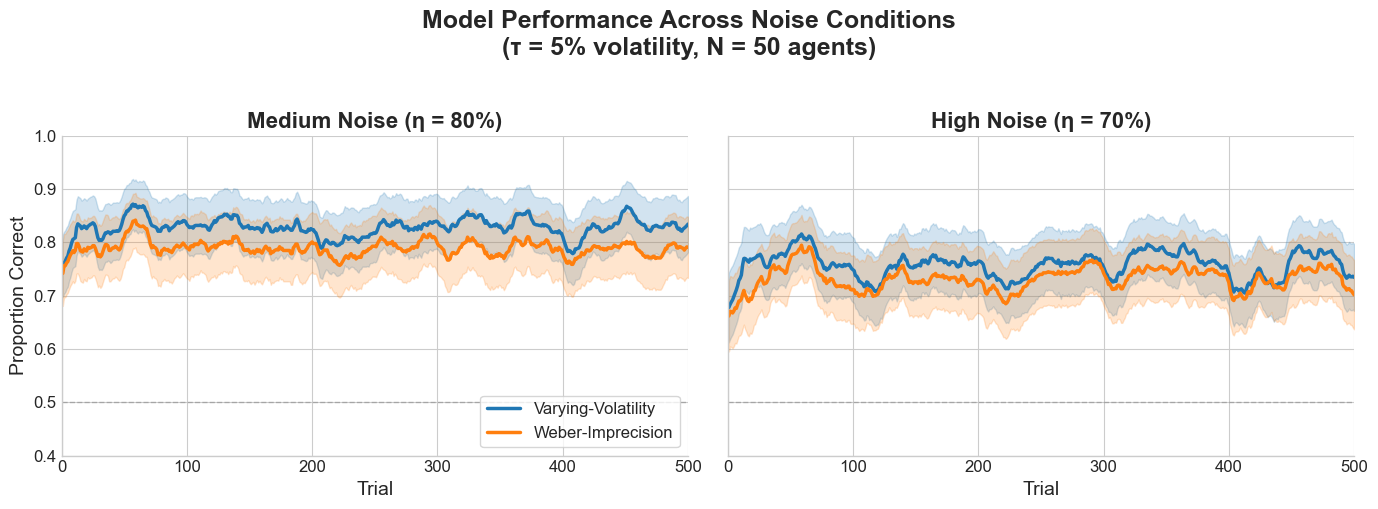

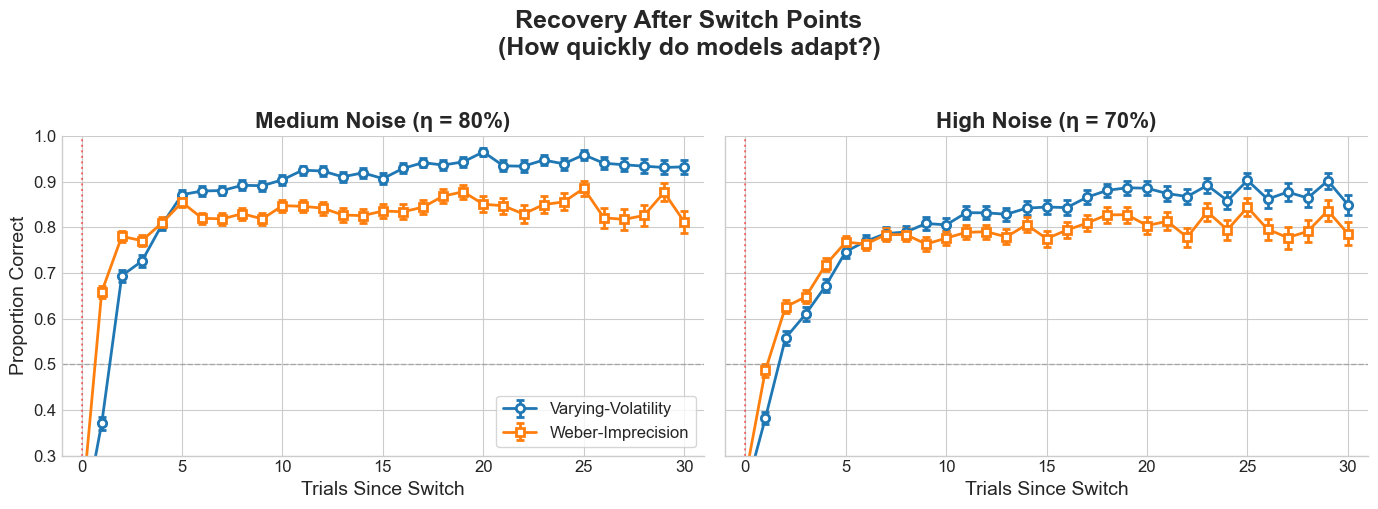


 Welch t-test results:
 Medium Noise: t=8.09, p=0.000000000
 High Noise: t=3.84, p=0.000229601
Welch's t-test: t = 8.095e+00, p = 3.088e-12


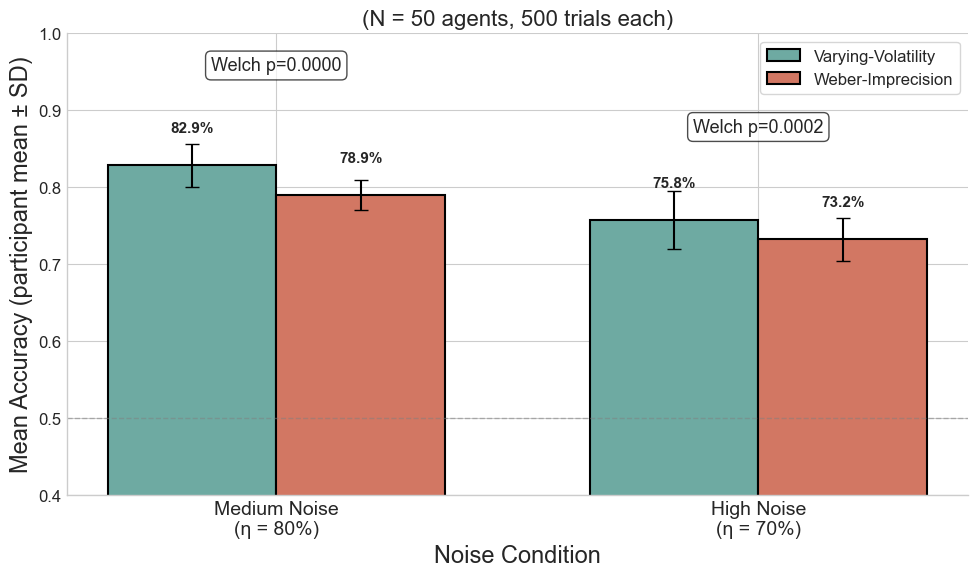

In [ ]:
from scipy.stats import ttest_ind

# ============================================================
# QUICK SUMMARY
# ============================================================
print("\n" + "=" * 60)
print(" QUICK SUMMARY")
print("=" * 60)

df_results = pd.read_csv("1.simulation_data/model_simulation_results.csv")

# Noise conditions (feedback reliability η) = 
NOISE_CONDITIONS = {
    "medium_noise": 0.8, 
    "high_noise": 0.7
 }

TRIALS = 500   
VOLATILITY = 0.05          # Fixed 5% switch probability (τ = 0.05, stable)
N_RUNS = 50              # 50 simulated "participants" per model (100 total) Findling: 'In each environment, we simulated each model 50 times'


summary = df_results.groupby(["model", "condition"]).agg({
    "is_correct": ["mean", "std"],
    "confidence": "mean",
    "participant_id": "nunique"
}).round(3)
summary.columns = ["accuracy_mean", "accuracy_std", "confidence_mean", "n_participants"]
print(summary)

# Show switch-point analysis preview
print("\n ACCURACY BY TRIALS SINCE SWITCH (first 10 trials after switch):")
switch_analysis = df_results[df_results["trials_since_switch"] <= 10].groupby(
    ["model", "trials_since_switch"]
)["is_correct"].mean().unstack(level=0).round(3)
print(switch_analysis)


# ============================================================
# SIGNIFICANCE TESTING (participant-level; between-subject)
# ============================================================
from scipy import stats
import numpy as np

# Aggregate to participant-level accuracy to avoid trial-level pseudo-replication
participant_acc = (
    df_results
    .groupby(["model", "condition", "participant_id"])["is_correct"]
    .mean()
    .reset_index()
)

def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    if pooled == 0:
        return np.nan
    return (a.mean() - b.mean()) / pooled

# Overall comparison (all conditions pooled)
vv_all = participant_acc[participant_acc["model"] == "VarVol"]["is_correct"]
wb_all = participant_acc[participant_acc["model"] == "Weber"]["is_correct"]
t_all, p_all = stats.ttest_ind(vv_all, wb_all, equal_var=False)  # Welch
d_all = cohens_d(vv_all, wb_all)

overall_stats_text = (
    "Overall accuracy (participant mean)\n"
    f"VarVol: {vv_all.mean():.3f} ± {vv_all.std(ddof=1):.3f}\n"
    f"Weber:  {wb_all.mean():.3f} ± {wb_all.std(ddof=1):.3f}\n"
    f"Welch t={t_all:.2f}, p={p_all:.4f}, d={d_all:.2f}"
)

print("\n" + "=" * 60)
print(" OVERALL MODEL PERFORMANCE (participant-level)")
print("=" * 60)
print(overall_stats_text)

# Per-condition comparison
condition_stats = {}
for cond in participant_acc["condition"].unique():
    vv = participant_acc[(participant_acc["model"] == "VarVol") & (participant_acc["condition"] == cond)]["is_correct"]
    wb = participant_acc[(participant_acc["model"] == "Weber") & (participant_acc["condition"] == cond)]["is_correct"]
    t, p = stats.ttest_ind(vv, wb, equal_var=False)
    d = cohens_d(vv, wb)
    condition_stats[cond] = (vv.mean(), wb.mean(), t, p, d)

print("\n" + "=" * 60)
print(" MODEL PERFORMANCE BY CONDITION")
print("=" * 60)
for cond, (vv_m, wb_m, t, p, d) in condition_stats.items():
    print(f"{cond}: VarVol={vv_m:.3f}, Weber={wb_m:.3f} | Welch t={t:.2f}, p={p:.4f}, d={d:.2f}")


# ============================================================
# VISUALISATIONS 
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Set report-ready defaults
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ============================================================
# FIGURE 1: Accuracy Over Time by Model and Condition
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Smooth with rolling window for cleaner curves
window = 20

for i, (condition_name, beta) in enumerate(NOISE_CONDITIONS.items()):
    ax = axes[i]
    
    # Get data for this condition
    df_cond = df_results[df_results["condition"] == condition_name]
    
    for model, color, label in [("VarVol", "#1f77b4", "Varying-Volatility"), 
                                  ("Weber", "#ff7f0e", "Weber-Imprecision")]:
        df_model = df_cond[df_cond["model"] == model]
        
        # Compute mean accuracy per trial
        acc_per_trial = df_model.groupby("trial")["is_correct"].mean()
        trials = acc_per_trial.index.values
        acc = acc_per_trial.values
        
        # Smooth
        acc_smooth = pd.Series(acc).rolling(window, center=True, min_periods=1).mean()
        
        # Compute SEM for shading
        sem_per_trial = df_model.groupby("trial")["is_correct"].sem()
        sem_smooth = pd.Series(sem_per_trial.values).rolling(window, center=True, min_periods=1).mean()
        
        ax.plot(trials, acc_smooth, color=color, linewidth=2.5, label=label)
        ax.fill_between(trials, acc_smooth - sem_smooth, acc_smooth + sem_smooth, color=color, alpha=0.2)
    
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, linewidth=1)
    ax.set_xlabel("Trial", fontsize=14)
    ax.set_ylim(0.4, 1.0)
    ax.set_xlim(0, TRIALS)
    
    noise_pct = int(beta * 100)
    ax.set_title(f"{'Medium' if noise_pct == 80 else 'High'} Noise (η = {noise_pct}%)", 
                 fontsize=16, fontweight='bold')
    
    if i == 0:
        ax.set_ylabel("Proportion Correct", fontsize=14)
        ax.legend(loc="lower right", frameon=True, fancybox=True)

fig.suptitle(f"Model Performance Across Noise Conditions\n(τ = {VOLATILITY:.0%} volatility, N = {N_RUNS} agents)", 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("result_figures/accuracy_over_time.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2: Switch-Point Recovery Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

max_trials_after_switch = 30

for i, (condition_name, beta) in enumerate(NOISE_CONDITIONS.items()):
    ax = axes[i]
    
    df_cond = df_results[(df_results["condition"] == condition_name) & 
                          (df_results["trials_since_switch"] <= max_trials_after_switch)]
    
    for model, color, marker, label in [("VarVol", "#1f77b4", "o", "Varying-Volatility"), 
                                          ("Weber", "#ff7f0e", "s", "Weber-Imprecision")]:
        df_model = df_cond[df_cond["model"] == model]
        
        # Mean accuracy by trials since switch
        recovery = df_model.groupby("trials_since_switch")["is_correct"].agg(["mean", "sem"])
        
        ax.errorbar(recovery.index, recovery["mean"], yerr=recovery["sem"],
                    color=color, marker=marker, markersize=6, linewidth=2, 
                    capsize=3, label=label, markerfacecolor='white', markeredgewidth=2)
    
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, linewidth=1)
    ax.axvline(0, color="red", linestyle=":", alpha=0.5, linewidth=1.5)
    ax.set_xlabel("Trials Since Switch", fontsize=14)
    ax.set_xlim(-1, max_trials_after_switch + 1)
    ax.set_ylim(0.3, 1.0)
    
    noise_pct = int(beta * 100)
    ax.set_title(f"{'Medium' if noise_pct == 80 else 'High'} Noise (η = {noise_pct}%)", 
                 fontsize=16, fontweight='bold')
    
    if i == 0:
        ax.set_ylabel("Proportion Correct", fontsize=14)
        ax.legend(loc="lower right", frameon=True, fancybox=True)

fig.suptitle("Recovery After Switch Points\n(How quickly do models adapt?)", 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("result_figures/switch_recovery.png", dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# FIGURE 3: Model Comparison Bar Chart (mean ± SD + Welch p)
# ============================================================
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Participant-level accuracy (avoid pseudo-replication)
participant_acc = (
    df_results
    .groupby(["model", "condition", "participant_id"])["is_correct"]
    .mean()
    .reset_index()
)

# Summary stats (mean ± SD)
summary_data = participant_acc.groupby(["model", "condition"])["is_correct"].agg(
    mean="mean", std="std", n="count"
).reset_index()

x = np.arange(2)  # Two conditions
width = 0.35

# VarVol bars
vv_data = summary_data[summary_data["model"] == "VarVol"]
vv_medium = vv_data[vv_data["condition"] == "medium_noise"]
vv_high = vv_data[vv_data["condition"] == "high_noise"]

# Weber bars
wb_data = summary_data[summary_data["model"] == "Weber"]
wb_medium = wb_data[wb_data["condition"] == "medium_noise"]
wb_high = wb_data[wb_data["condition"] == "high_noise"]

bars1 = ax.bar(
    x - width/2,
    [vv_medium["mean"].values[0], vv_high["mean"].values[0]],
    width,
    yerr=[vv_medium["std"].values[0], vv_high["std"].values[0]],
    label="Varying-Volatility",
    color="#6eaaa2" ,
    capsize=5,
    edgecolor="black",
    linewidth=1.5
)
bars2 = ax.bar(
    x + width/2,
    [wb_medium["mean"].values[0], wb_high["mean"].values[0]],
    width,
    yerr=[wb_medium["std"].values[0], wb_high["std"].values[0]],
    label="Weber-Imprecision",
    color= "#d27763" ,
    capsize=5,
    edgecolor="black",
    linewidth=1.5
)

ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, linewidth=1)

ax.set_ylabel("Mean Accuracy (participant mean ± SD)", fontsize=17)
ax.set_xlabel("Noise Condition", fontsize=17)
ax.set_title(
    f"(N = {N_RUNS} agents, {TRIALS} trials each)",
    fontsize=16,
)
ax.set_xticks(x)
ax.set_xticklabels([
    f"Medium Noise\n(η = {int(NOISE_CONDITIONS['medium_noise']*100)}%)",
    f"High Noise\n(η = {int(NOISE_CONDITIONS['high_noise']*100)}%)"
], fontsize=14)
ax.set_ylim(0.4, 1.0)
ax.legend(loc="upper right", frameon=True, fancybox=True, fontsize=12)

# Welch t-tests per condition (participant-level)
def welch_p(cond):
    vv = participant_acc[(participant_acc["model"] == "VarVol") & (participant_acc["condition"] == cond)]["is_correct"]
    wb = participant_acc[(participant_acc["model"] == "Weber") & (participant_acc["condition"] == cond)]["is_correct"]
    t, p = stats.ttest_ind(vv, wb, equal_var=False)
    return t, p

t_med, p_med = welch_p("medium_noise")
t_high, p_high = welch_p("high_noise")

# Medium condition's t-test results with e-notation
vv = participant_acc[(participant_acc["model"] == "VarVol") & (participant_acc["condition"] == "medium_noise")]["is_correct"]
wb = participant_acc[(participant_acc["model"] == "Weber") & (participant_acc["condition"] == "medium_noise")]["is_correct"]
stat, p = ttest_ind(vv, wb, equal_var=False)

print(f"\n Welch t-test results:"
      f"\n Medium Noise: t={t_med:.2f}, p={p_med:.9f}"
      f"\n High Noise: t={t_high:.2f}, p={p_high:.9f}")
# Print results with e-notation
print(f"Welch's t-test: t = {stat:.3e}, p = {p:.3e}")

# Add p-values above groups
ax.text(x[0], 0.97, f"Welch p={p_med:.4f}", ha="center", va="top", fontsize=13,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
ax.text(x[1], 0.89, f"Welch p={p_high:.4f}", ha="center", va="top", fontsize=13,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

# Value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1%}",
            xy=(bar.get_x() + bar.get_width() / 2, height + 0.03),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

plt.tight_layout()
plt.savefig("result_figures/model_comparison_bars.png", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = participant_acc

# Two-way ANOVA
model = ols('is_correct ~ C(model) * C(condition)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                         sum_sq     df           F        PR(>F)
C(model)               0.052100    1.0   62.014011  2.281441e-13
C(condition)           0.205569    1.0  244.686382  2.498443e-36
C(model):C(condition)  0.002367    1.0    2.817083  9.485941e-02
Residual               0.164666  196.0         NaN           NaN


### Step 6: Stress test noise vs volatility 

In [18]:
# ============================================================
#  STRESS TEST: When does Weber ACTUALLY break?
# ============================================================
# Test the hypothesis: Weber fails with HIGH NOISE + HIGH VOLATILITY together

print("="*70)
print(" STRESS TEST: Finding Weber's breaking point")
print("="*70)
print("Testing NOISE × VOLATILITY interaction...")
print()


# Agent settings (Findling et al. 2021 defaults)
# Using default parameters from the original Findling et al. code. for SIMULATION
# From varvol_forward/bootstrap.py: beta_softmax=1., epsilon not specified (=0)
# From noisy_forward/bootstrap.py:  beta_softmax= None., lambda_noise=0.9, eta_noise=0.1, epsilon_softmax=0.

# Particle settings and runs
N_THETA = 500              # Number of parameter particles # simulation uses 1000, fitting only 200, 500 for speed
N_STATE = 500              # Number of state particles # simulation uses 1000 for VV, 2000 for W, fitting only 200, 500 for speed


agent_kwargs_varvol = {
    "num_theta": N_THETA, 
    "num_state_particles": N_STATE,
    "beta_softmax": None,       # Findling default for simulation - argmax policy for simulations
}
agent_kwargs_weber = {
    "num_theta": N_THETA,
    "num_state_particles": N_STATE*2, # Weber runs on more particles (2000 in original, while VV uses only 1000, we half both - using 1000 for W and 500 for VV for speed here)
    "lambdaa": 0.9,            # Findling default for simulation 
    "mu": 0.0,                 # Findling default for simulation
    "beta_softmax": None,       # Findling default for simulation - argmax policy for simulations
}


# Test grid
NOISE_LEVELS = [1.0, 0.9, 0.8, 0.7, 0.6]  # η values (lower = more noise)
VOLATILITY_LEVELS = [0, 0.10, 0.20, 0.30, 0.40]  # τ values (higher = more volatile)
N_RUNS = 5
TRIALS = 300 # Short for speed; we just want to see where Weber breaks, not precise estimates 

import time
MASTER_SEED = int(time.time()) % 100000  # Changes each run
print(f"Master seed: {MASTER_SEED}")

# Generate tasks
def generate_simple_task(trials, tau, beta, seed=42):
    """Generate a simple bandit task for quick comparison."""
    rng = np.random.default_rng(seed)
    stimuli = np.zeros(trials, dtype=int)
    tau_array = np.full(trials, tau)
    latent = np.zeros(trials, dtype=int)
    latent[0] = rng.integers(2)
    for t in range(1, trials):
        if rng.random() < tau:
            latent[t] = 1 - latent[t - 1]
        else:
            latent[t] = latent[t - 1]
    traps = rng.random(trials) > beta
    return VolatileBanditTask(
        stimuli=stimuli, latent_states=latent, switch_prob=tau_array,
        traps=traps, correct_actions=latent.copy(), beta=beta
    )

# Store results
varvol_results = np.zeros((len(NOISE_LEVELS), len(VOLATILITY_LEVELS)))
weber_results = np.zeros((len(NOISE_LEVELS), len(VOLATILITY_LEVELS)))

for i, eta in enumerate(NOISE_LEVELS):
    for j, tau in enumerate(VOLATILITY_LEVELS):
        vv_accs = []
        wb_accs = []
        
        for run in range(N_RUNS):
            task = generate_simple_task(TRIALS, tau, eta, seed=MASTER_SEED + run*100)
            
            # VarVol
            env = TwoArmedBanditEnv(task)
            env.reset()
            agent = ForwardVaryingVolatilityAgent(seed=MASTER_SEED + run*100+1, **agent_kwargs_varvol)
            correct = []
            for t in range(TRIALS):
                action, _ = agent.act(task.stimuli[t])
                _, reward, correct_action = env.step(action)
                agent.observe(reward)
                correct.append(int(action == correct_action))
            vv_accs.append(np.mean(correct))
            
            # Weber
            env = TwoArmedBanditEnv(task)
            env.reset()
            agent = WeberImprecisionAgent(seed=MASTER_SEED + run*100+1, **agent_kwargs_weber)
            correct = []
            for t in range(TRIALS):
                action, _ = agent.act(task.stimuli[t])
                _, reward, correct_action = env.step(action)
                agent.observe(reward)
                correct.append(int(action == correct_action))
            wb_accs.append(np.mean(correct))
        
        varvol_results[i, j] = np.mean(vv_accs)
        weber_results[i, j] = np.mean(wb_accs)
        
        # Progress indicator
        print(f"   η={eta:.0%} noise, τ={tau:.0%} volatility: VarVol={varvol_results[i,j]:.1%}, Weber={weber_results[i,j]:.1%}")




 STRESS TEST: Finding Weber's breaking point
Testing NOISE × VOLATILITY interaction...

Master seed: 40491
   η=100% noise, τ=0% volatility: VarVol=99.9%, Weber=99.9%
   η=100% noise, τ=10% volatility: VarVol=89.6%, Weber=86.3%
   η=100% noise, τ=20% volatility: VarVol=78.6%, Weber=76.2%
   η=100% noise, τ=30% volatility: VarVol=67.1%, Weber=67.8%
   η=100% noise, τ=40% volatility: VarVol=56.3%, Weber=54.8%
   η=90% noise, τ=0% volatility: VarVol=98.3%, Weber=94.6%
   η=90% noise, τ=10% volatility: VarVol=83.1%, Weber=82.3%
   η=90% noise, τ=20% volatility: VarVol=73.7%, Weber=74.5%
   η=90% noise, τ=30% volatility: VarVol=64.4%, Weber=64.1%
   η=90% noise, τ=40% volatility: VarVol=57.1%, Weber=55.1%
   η=80% noise, τ=0% volatility: VarVol=94.3%, Weber=85.0%
   η=80% noise, τ=10% volatility: VarVol=76.3%, Weber=77.0%
   η=80% noise, τ=20% volatility: VarVol=68.0%, Weber=67.7%
   η=80% noise, τ=30% volatility: VarVol=60.5%, Weber=59.9%
   η=80% noise, τ=40% volatility: VarVol=55.3%, Web

 Results arrays created!
   Shape: (5, 5) (noise × volatility)
   Noise levels: [1.0, 0.9, 0.8, 0.7, 0.6]
   Volatility levels: [0, 0.1, 0.2, 0.3, 0.4]


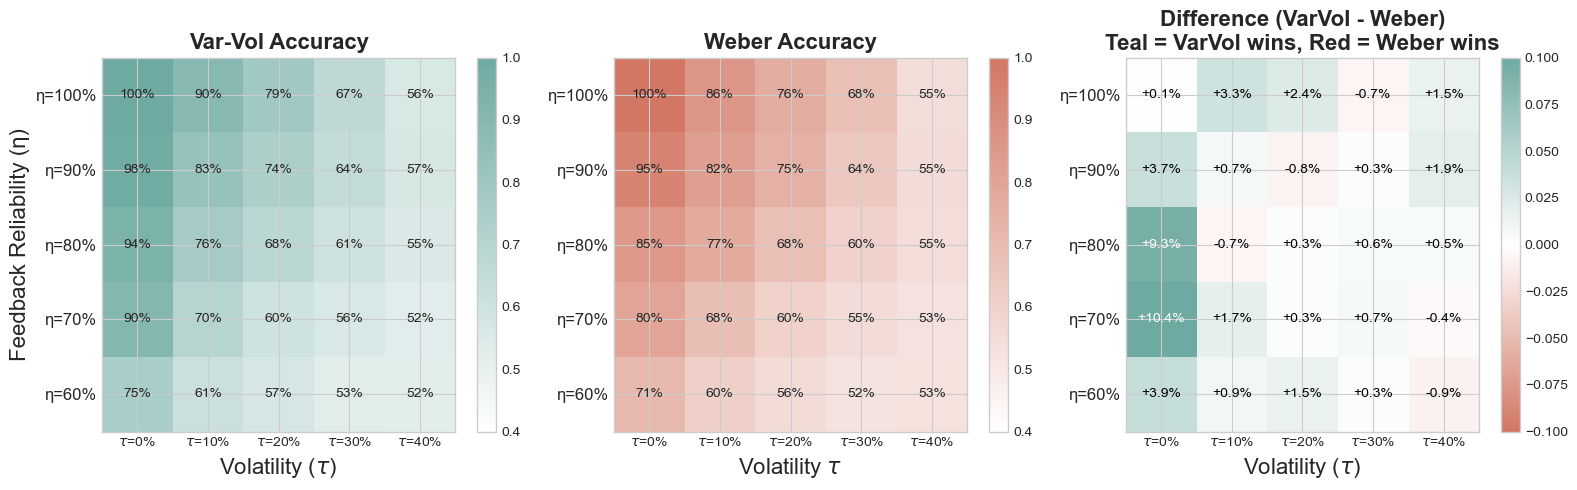


 ANALYSIS

 VarVol's BIGGEST advantage:
   η=70%, τ=0%
   Difference: +10.4%

 Weber's BEST relative performance:
   η=60%, τ=40%
   Difference: -0.9%

 HYPOTHESIS TEST: Does NOISE×VOLATILITY hurt Weber more?
   Clean + Stable (η=90%, τ=5%):     Δ = +0.1%
   Noisy + Volatile (η=55%, τ=30%):  Δ = -0.9%
    NO! Weber is surprisingly resilient even in extreme conditions.


In [30]:
from matplotlib.colors import LinearSegmentedColormap

# Results from stress test run (Master seed: 97961)
# Format: varvol_results[noise_idx, vol_idx] and weber_results[noise_idx, vol_idx]

# # Grid definition (must match Step 6)
# noise_levels = [0.90, 0.80, 0.70, 0.60, 0.55]  # η (beta) values
# volatility_levels = [0.05, 0.10, 0.20, 0.30]   # τ values

# # VarVol results: rows = noise levels, cols = volatility levels
# # VALUES AS DECIMALS (divide by 100)
# varvol_results = np.array([
#     # τ=5%   τ=10%  τ=20%  τ=30%
#     [0.889, 0.817, 0.710, 0.613],  # η=90%
#     [0.837, 0.757, 0.651, 0.563],  # η=80%
#     [0.800, 0.709, 0.603, 0.543],  # η=70%
#     [0.683, 0.619, 0.519, 0.504],  # η=60%
#     [0.605, 0.573, 0.499, 0.485],  # η=55%
# ])

# # Weber results: rows = noise levels, cols = volatility levels
# weber_results = np.array([
#     # τ=5%   τ=10%  τ=20%  τ=30%
#     [0.868, 0.827, 0.705, 0.613],  # η=90%
#     [0.777, 0.747, 0.657, 0.572],  # η=80%
#     [0.757, 0.694, 0.601, 0.538],  # η=70%
#     [0.680, 0.629, 0.532, 0.507],  # η=60%
#     [0.604, 0.571, 0.502, 0.495],  # η=55%
# ])

# noise_levels = [1.0, 0.8, 0.6]  # η values (lower = more noise)
# volatility_levels = [0, 0.20, 0.40]  # τ values (higher = more volatile)

noise_levels = [1.0, 0.9, 0.8, 0.7, 0.6] 
volatility_levels = [0, 0.10, 0.20, 0.30, 0.40]


print(" Results arrays created!")
print(f"   Shape: {varvol_results.shape} (noise × volatility)")
print(f"   Noise levels: {noise_levels}")
print(f"   Volatility levels: {volatility_levels}")

# Compute differences (VarVol - Weber, positive = VarVol wins)
diff_results = varvol_results - weber_results

# Create heatmap
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Define your custom colors
colors = ["#d27763","#ffffff", "#6eaaa2" ]  # varvol → white → weber
# Create the colormap
custom_cmap = LinearSegmentedColormap.from_list("varvol_weber_cmap", colors)
varvol_cmap = LinearSegmentedColormap.from_list("varvol", ["#ffffff", "#6eaaa2"])
weber_cmap = LinearSegmentedColormap.from_list("weber", ["#ffffff", "#d27763"])


# Plot 1: VarVol accuracy
im1 = axes[0].imshow(varvol_results, cmap=varvol_cmap, vmin=0.4, vmax=1.0, aspect='auto')
axes[0].set_title("Var-Vol Accuracy", fontsize=16, fontweight='bold')
axes[0].set_xticks(range(len(volatility_levels)))
axes[0].set_xticklabels([f"$\\tau$={v:.0%}" for v in volatility_levels])
axes[0].set_yticks(range(len(noise_levels)))
axes[0].set_yticklabels([f"η={n:.0%}" for n in noise_levels], fontsize=12)
axes[0].set_xlabel("Volatility ($\\tau$)", fontsize=16)
axes[0].set_ylabel("Feedback Reliability (η)", fontsize=16)
for i in range(len(noise_levels)):
    for j in range(len(volatility_levels)):
        axes[0].text(j, i, f"{varvol_results[i,j]:.0%}", ha='center', va='center', fontsize=10)
plt.colorbar(im1, ax=axes[0])

# Plot 2: Weber accuracy
im2 = axes[1].imshow(weber_results, cmap=weber_cmap, vmin=0.4, vmax=1.0, aspect='auto')
axes[1].set_title("Weber Accuracy", fontsize=16, fontweight='bold')
axes[1].set_xticks(range(len(volatility_levels)))
axes[1].set_xticklabels([f"$\\tau$={v:.0%}" for v in volatility_levels])
axes[1].set_yticks(range(len(noise_levels)))
axes[1].set_yticklabels([f"η={n:.0%}" for n in noise_levels], fontsize=12)
axes[1].set_xlabel("Volatility $\\tau$", fontsize=16)
for i in range(len(noise_levels)):
    for j in range(len(volatility_levels)):
        axes[1].text(j, i, f"{weber_results[i,j]:.0%}", ha='center', va='center', fontsize=10)
plt.colorbar(im2, ax=axes[1])

# Plot 3: Difference (VarVol - Weber)
im3 = axes[2].imshow(diff_results, cmap=custom_cmap, vmin=-0.1, vmax=0.1, aspect='auto')
axes[2].set_title("Difference (VarVol - Weber)\nTeal = VarVol wins, Red = Weber wins", fontsize=16, fontweight='bold')
axes[2].set_xticks(range(len(volatility_levels)))
axes[2].set_xticklabels([f"$\\tau$={v:.0%}" for v in volatility_levels])
axes[2].set_yticks(range(len(noise_levels)))
axes[2].set_yticklabels([f"η={n:.0%}" for n in noise_levels], fontsize=12)
axes[2].set_xlabel("Volatility ($\\tau$)", fontsize=16)
for i in range(len(noise_levels)):
    for j in range(len(volatility_levels)):
        color = 'white' if abs(diff_results[i,j]) > 0.05 else 'black'
        axes[2].text(j, i, f"{diff_results[i,j]:+.1%}", ha='center', va='center', fontsize=10, color=color)
plt.colorbar(im3, ax=axes[2])

#plt.suptitle(" STRESS TEST: Noise × Volatility Interaction", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find breaking point
print("\n" + "="*70)
print(" ANALYSIS")
print("="*70)

# Where does VarVol have the biggest advantage?
max_diff_idx = np.unravel_index(np.argmax(diff_results), diff_results.shape)
print(f"\n VarVol's BIGGEST advantage:")
print(f"   η={noise_levels[max_diff_idx[0]]:.0%}, τ={volatility_levels[max_diff_idx[1]]:.0%}")
print(f"   Difference: {diff_results[max_diff_idx]:+.1%}")

# Where does Weber do surprisingly well?
min_diff_idx = np.unravel_index(np.argmin(diff_results), diff_results.shape)
print(f"\n Weber's BEST relative performance:")
print(f"   η={noise_levels[min_diff_idx[0]]:.0%}, τ={volatility_levels[min_diff_idx[1]]:.0%}")
print(f"   Difference: {diff_results[min_diff_idx]:+.1%}")

# Check hypothesis: Does high noise + high volatility hurt Weber more?
corner_diff = diff_results[-1, -1]  # Bottom-right: highest noise + highest volatility
clean_stable_diff = diff_results[0, 0]  # Top-left: clean + stable
print(f"\n HYPOTHESIS TEST: Does NOISE×VOLATILITY hurt Weber more?")
print(f"   Clean + Stable (η=90%, τ=5%):     Δ = {clean_stable_diff:+.1%}")
print(f"   Noisy + Volatile (η=55%, τ=30%):  Δ = {corner_diff:+.1%}")
if corner_diff > clean_stable_diff + 0.03:
    print(f"    YES! VarVol's advantage grows when BOTH noise and volatility are high.")
else:
    print(f"    NO! Weber is surprisingly resilient even in extreme conditions.")


======================================================================
PREVIOUS STRESS TEST RESULTS 
======================================================================

Testing NOISE × VOLATILITY interaction...

Master seed: 97961
   η=90% noise, τ=5% volatility: VarVol=88.9%, Weber=86.8%
   η=90% noise, τ=10% volatility: VarVol=81.7%, Weber=82.7%
   η=90% noise, τ=20% volatility: VarVol=71.0%, Weber=70.5%
   η=90% noise, τ=30% volatility: VarVol=61.3%, Weber=61.3%
   η=80% noise, τ=5% volatility: VarVol=83.7%, Weber=77.7%
   η=80% noise, τ=10% volatility: VarVol=75.7%, Weber=74.7%
   η=80% noise, τ=20% volatility: VarVol=65.1%, Weber=65.7%
   η=80% noise, τ=30% volatility: VarVol=56.3%, Weber=57.2%
   η=70% noise, τ=5% volatility: VarVol=80.0%, Weber=75.7%
   η=70% noise, τ=10% volatility: VarVol=70.9%, Weber=69.4%
   η=70% noise, τ=20% volatility: VarVol=60.3%, Weber=60.1%
   η=70% noise, τ=30% volatility: VarVol=54.3%, Weber=53.8%
   η=60% noise, τ=5% volatility: VarVol=68.3%, Weber=68.0%
   η=60% noise, τ=10% volatility: VarVol=61.9%, Weber=62.9%
   η=60% noise, τ=20% volatility: VarVol=51.9%, Weber=53.2%
   η=60% noise, τ=30% volatility: VarVol=50.4%, Weber=50.7%
   η=55% noise, τ=5% volatility: VarVol=60.5%, Weber=60.4%
   η=55% noise, τ=10% volatility: VarVol=57.3%, Weber=57.1%
   η=55% noise, τ=20% volatility: VarVol=49.9%, Weber=50.2%
   η=55% noise, τ=30% volatility: VarVol=48.5%, Weber=49.5%


Testing NOISE × VOLATILITY interaction...

Master seed: 23546
   η=100% noise, τ=0% volatility: VarVol=99.9%, Weber=99.7%
   η=100% noise, τ=20% volatility: VarVol=78.7%, Weber=76.1%
   η=100% noise, τ=40% volatility: VarVol=56.6%, Weber=57.1%
   η=80% noise, τ=0% volatility: VarVol=94.5%, Weber=82.3%
   η=80% noise, τ=20% volatility: VarVol=65.3%, Weber=65.9%
   η=80% noise, τ=40% volatility: VarVol=52.8%, Weber=52.9%
   η=60% noise, τ=0% volatility: VarVol=73.9%, Weber=71.1%
   η=60% noise, τ=20% volatility: VarVol=54.7%, Weber=53.6%
   η=60% noise, τ=40% volatility: VarVol=50.5%, Weber=51.7%

# APPENDIX SECTION

In [ ]:
# ============================================================
# POWER ANALYSIS: How many runs do we need?
# ============================================================
# Estimate the variance and determine appropriate sample sizes

print("="*70)
print(" POWER ANALYSIS: How many runs do we need?")
print("="*70)

# Run a quick sample to estimate variance
SAMPLE_RUNS = 30
TRIALS = 50
tau = 0.05
beta = 0.8

print(f"\nRunning {SAMPLE_RUNS} samples to estimate variance...")

varvol_accs = []
weber_accs = []

for run in range(SAMPLE_RUNS):
    task = generate_simple_task(TRIALS, tau, beta, seed=run*100)
    
    # VarVol
    env = TwoArmedBanditEnv(task)
    env.reset()
    agent = ForwardVaryingVolatilityAgent(seed=run*100+1, **agent_kwargs_varvol)
    correct = []
    for t in range(TRIALS):
        action, _ = agent.act(task.stimuli[t])
        _, reward, correct_action = env.step(action)
        agent.observe(reward)
        correct.append(int(action == correct_action))
    varvol_accs.append(np.mean(correct))
    
    # Weber
    env = TwoArmedBanditEnv(task)
    env.reset()
    agent = WeberImprecisionAgent(seed=run*100+1, **agent_kwargs_weber)
    correct = []
    for t in range(TRIALS):
        action, _ = agent.act(task.stimuli[t])
        _, reward, correct_action = env.step(action)
        agent.observe(reward)
        correct.append(int(action == correct_action))
    weber_accs.append(np.mean(correct))

# Calculate statistics
vv_mean, vv_std = np.mean(varvol_accs), np.std(varvol_accs)
wb_mean, wb_std = np.mean(weber_accs), np.std(weber_accs)
diff_mean = vv_mean - wb_mean
diff_std = np.std([v - w for v, w in zip(varvol_accs, weber_accs)])

print(f"\n{'Model':<10} {'Mean':<10} {'Std Dev':<10} {'Std Error (N=30)':<15}")
print("-"*50)
print(f"{'VarVol':<10} {vv_mean:<10.1%} {vv_std:<10.1%} {vv_std/np.sqrt(SAMPLE_RUNS):<15.1%}")
print(f"{'Weber':<10} {wb_mean:<10.1%} {wb_std:<10.1%} {wb_std/np.sqrt(SAMPLE_RUNS):<15.1%}")
print(f"\nDifference: {diff_mean:+.1%} ± {diff_std:.1%}")

# Power analysis
print("\n" + "="*70)
print(" STANDARD ERROR BY SAMPLE SIZE")
print("="*70)
print(f"\n{'N Runs':<10} {'SE (VarVol)':<15} {'SE (Weber)':<15} {'SE (Diff)':<15} {'Can detect':<20}")
print("-"*75)

for n in [10, 20, 40, 100, 200, 500]:
    se_vv = vv_std / np.sqrt(n)
    se_wb = wb_std / np.sqrt(n)
    se_diff = diff_std / np.sqrt(n)
    detectable = f">{2*se_diff:.1%} difference"
    print(f"{n:<10} {se_vv:<15.1%} {se_wb:<15.1%} {se_diff:<15.1%} {detectable:<20}")

# Recommendation
print("\n" + "="*70)
print("💡 RECOMMENDATION")
print("="*70)
observed_diff = abs(diff_mean)
if observed_diff < 0.02:
    print(f"\nObserved difference: {diff_mean:+.1%} (very small)")
    print("To confidently say 'models are equivalent', you need tight confidence intervals.")
    needed_n = int((2 * diff_std / 0.02) ** 2)  # To get SE < 1%
    print(f"Recommended: N ≥ {needed_n} runs to get SE < 1%")
else:
    needed_n = int((2 * diff_std / observed_diff) ** 2)
    print(f"\nObserved difference: {diff_mean:+.1%}")
    print(f"To reliably detect this difference: N ≥ {needed_n} runs")

print(f"\nFor your use case:")
print(f"  • Quick demo:           N = 40  (SE ≈ {vv_std/np.sqrt(40):.1%})")
print(f"  • Reliable comparison:  N = 100 (SE ≈ {vv_std/np.sqrt(100):.1%})")
print(f"  • Publication quality:  N = 200 (SE ≈ {vv_std/np.sqrt(200):.1%})")


📊 POWER ANALYSIS: How many runs do we need?

Running 30 samples to estimate variance...

Model      Mean       Std Dev    Std Error (N=30)
--------------------------------------------------
VarVol     73.6%      9.5%       1.7%           
Weber      70.4%      8.7%       1.6%           

Difference: +3.2% ± 8.9%

📈 STANDARD ERROR BY SAMPLE SIZE

N Runs     SE (VarVol)     SE (Weber)      SE (Diff)       Can detect          
---------------------------------------------------------------------------
10         3.0%            2.8%            2.8%            >5.6% difference    
20         2.1%            2.0%            2.0%            >4.0% difference    
40         1.5%            1.4%            1.4%            >2.8% difference    
100        1.0%            0.9%            0.9%            >1.8% difference    
200        0.7%            0.6%            0.6%            >1.3% difference    
500        0.4%            0.4%            0.4%            >0.8% difference    

💡 RECOMMENDATIO